==================== Teniamo soltanto i 5 componenti e sistemi più popolari ====================
Numero di righe prima del filtraggio: 57652
Numero di colonne prima della rimozione di colonne vuote: 169
Numero di righe dopo il filtraggio: 7998
Numero di colonne dopo la rimozione di colonne vuote: 56
==================== STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (a valle dei filtraggi) ====================
count      63.000000
mean      126.952381
std       288.294452
min         1.000000
25%        18.000000
50%        39.000000
75%       101.500000
max      1486.000000
Name: Flotta, dtype: float64


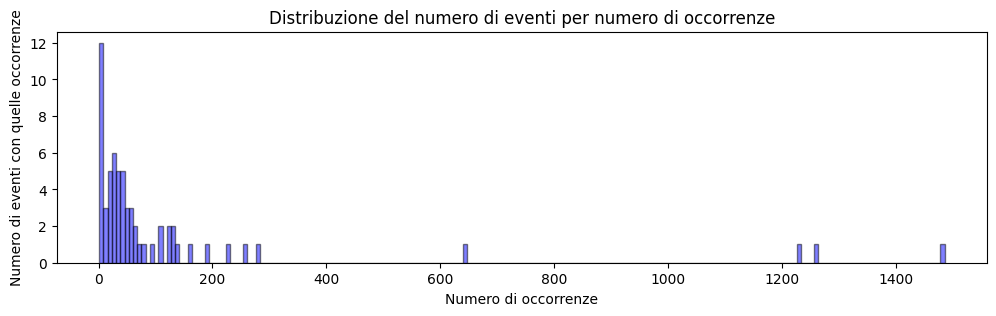

==================== PROPOSTA ====================
più raro è l'evento, più si può considerare essere un'anomalia.
Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un'anomalia???.
IL 25% degli eventi succede massimo 18.0  volte!
IL 50% degli eventi succede massimo 39.0  volte!
L 75% degli eventi succede massimo 101.5  volte!
Togliamo gli eventi il cui numero di occorrenze è una "coda" della distribuzione:
toglieremno  16   con molte occorrenze.
siamo rimasti con 63-16=47 eventi
==================== STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (DOPO ULTERIORI filtraggi) ====================
count    47.000000
mean     29.659574
std      23.083286
min       1.000000
25%       8.500000
50%      29.000000
75%      42.000000
max      94.000000
Name: Flotta, dtype: float64


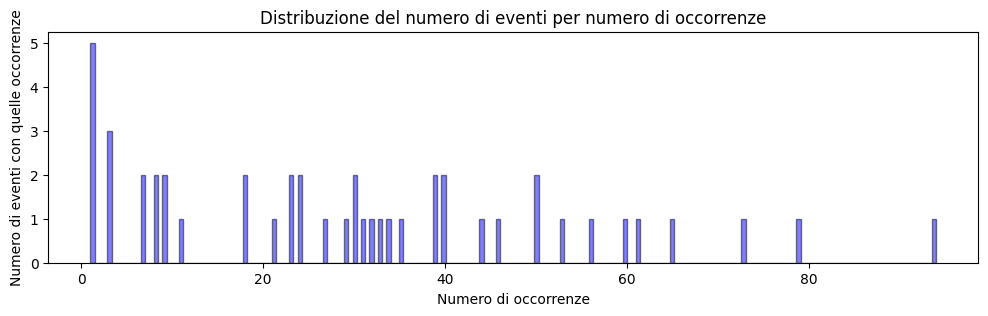

==================== PROPOSTA ====================
più raro è l'evento, più si può considerare essere un'anomalia.
Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un'anomalia???.
IL 25% degli eventi succede massimo 8.5  volte!
IL 50% degli eventi succede massimo 29.0  volte!
L 75% degli eventi succede massimo 42.0  volte!
Consideriamo anomalia tutto ciò che succede massimo 23.0 volte, corrispondete al quantile 0.4!
==================== Così facendo abbiamo: ====================
nel nostro dataset abbiamo 47 TIPI DI EVENTI diversi
sparsi in un totale di 1394 record
di cui 176 corrispondono ad anomalie


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import time
import numpy as np
import umap
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.optim as optim


#nomi delle colonne da generare
columns_to_generate = [
    'Durata','CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2',
    'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5',
    'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel', 'MDS_StatoMarcia', '_GPS_LAT',
    '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3', 'usB1BCilPres_M6', 'usB1BCilPres_M8',
    'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7', 'usB2BCilPres_M1', 'usB2BCilPres_M3',
    'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4', 'usB2BCilPres_T5', 'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

non_numeric_cols = [
        'Descrizione',
        'Timestamp chiusura',
        'Posizione',
        'Flotta',
        'Veicolo',
        'Codice',
        'Nome',
        'Test',
        'Sistema',
        'Componente',
        'Timestamp segnale']



dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

largest = 5 
anomalous_quantile = 0.4

print('='*20, f'Teniamo soltanto i {largest} componenti e sistemi più popolari','='*20)

top_components = list(dataset_new.groupby(['Componente']).count()['Flotta'].nlargest(largest).index)
top_sistems = list(dataset_new.groupby(['Sistema']).count()['Flotta'].nlargest(largest).index)

print(f"Numero di righe prima del filtraggio: {dataset.shape[0]}")
print(f"Numero di colonne prima della rimozione di colonne vuote: {dataset.shape[1]}")

dataset_new = dataset_new[dataset_new['Componente'].isin(top_components)]
dataset_new = dataset_new[dataset_new['Sistema'].isin(top_sistems)]

dataset_new = dataset_new.dropna(axis=1, how='all')
dataset_new = dataset_new.dropna()
dataset_new.set_index('Timestamp', inplace=True)
print(f"Numero di righe dopo il filtraggio: {dataset_new.shape[0]}")
print(f"Numero di colonne dopo la rimozione di colonne vuote: {dataset_new.shape[1]}")

events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (a valle dei filtraggi)','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')

print('Togliamo gli eventi il cui numero di occorrenze è una "coda" della distribuzione:')
all_events = set(dataset_new['Descrizione'].unique())
third_quantile_events = set(event_occurrences[event_occurrences <= events_and_occurrences.quantile(.75)].index)
upper_tail_events = all_events - third_quantile_events
events_to_remove = list(upper_tail_events)
events_to_keep = all_events - set(events_to_remove)
print('toglieremno ',len(upper_tail_events),"  con molte occorrenze.")

dataset_new = dataset_new[dataset_new['Descrizione'].isin(events_to_keep)]
eventi_totali = dataset_new['Descrizione'].nunique()
print(f"siamo rimasti con {len(all_events)}-{len(events_to_remove)}={eventi_totali} eventi")


events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (DOPO ULTERIORI filtraggi)','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')


min_occorrences_for_beign_normal = events_and_occurrences.quantile(anomalous_quantile)
print(f'Consideriamo anomalia tutto ciò che succede massimo {min_occorrences_for_beign_normal} volte, corrispondete al quantile {anomalous_quantile}!')

print('='*20, 'Così facendo abbiamo:','='*20)


print(f'nel nostro dataset abbiamo {eventi_totali} TIPI DI EVENTI diversi')
record_totali = len(dataset_new)
print(f'sparsi in un totale di {record_totali} record')

anomalies = event_occurrences[event_occurrences <= min_occorrences_for_beign_normal].index


record_anomalie = len(dataset_new[dataset_new['Descrizione'].isin(anomalies)])
print(f'di cui {record_anomalie} corrispondono ad anomalie')

In [9]:
X = dataset_new[columns_to_generate].values

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# Fit and transform the data
embedding = reducer.fit_transform(X.reshape(X.shape[0], -1))

anomalous = dataset_new['Descrizione'].isin(anomalies).values
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=anomalous, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by ANOMALOUS NATURE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Architecture of the MLP: 
<bound method Module.parameters of MLP(
  (manifold_layer): Linear(in_features=32, out_features=2, bias=True)
  (output_module): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Softmax(dim=1)
  )
  (main_stream): Sequential(
    (0): LayerNorm((42,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=42, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
  )
)>
Epoch 1, Test Accuracy: 0.8674
Epoch 2, Test Accuracy: 0.8674
Epoch 3, Test Accuracy: 0.8674
Epoch 4, Test Accuracy: 0.8674
Epoch 5, Test Accuracy: 0.8674
Epoch 6, Test Accuracy: 0.8674
Epoch 7, Test Accuracy: 0.8674
Epoch 8, Test Accuracy: 0.8889
Epoch 9, Test Accuracy: 0.8961
Epoch 10, Test Accuracy

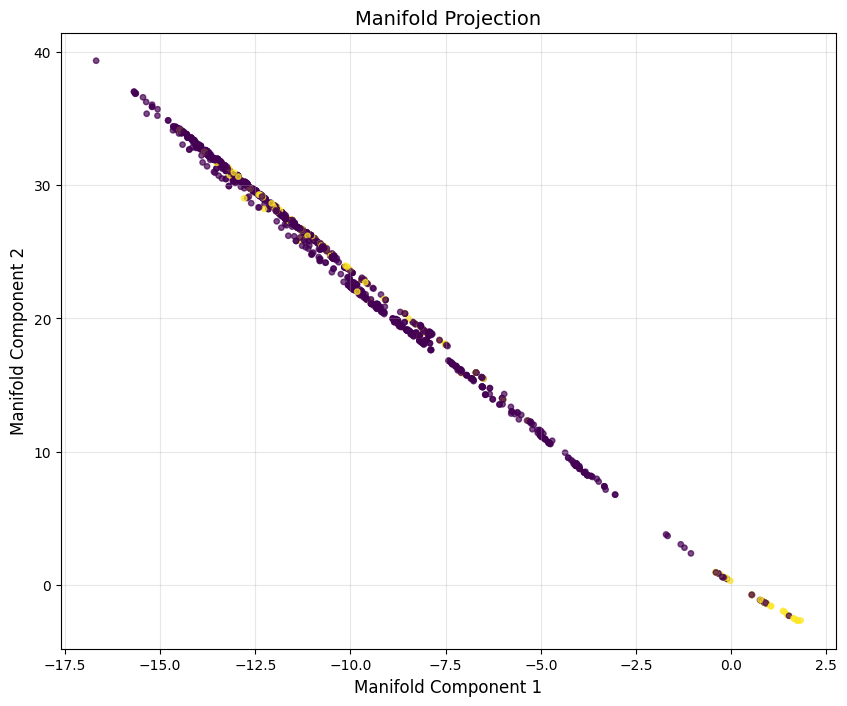

In [10]:
class MLP(nn.Module):
    def __init__(self, **kwargs):
        super(MLP, self).__init__()
        input_dim = kwargs.get('input_dim', 40)
        h_dim = kwargs.get('h_dim', 128)
        dropout = kwargs.get('dropout', 0.1)
        num_layers = kwargs.get('num_layers', 3)
        layer_norm = kwargs.get('layer_norm', False)
        output_dim = kwargs.get('output_dim',1)
        self.mode = kwargs.get('mode')
        
        main_stream = []

        if layer_norm:
            main_stream.append(nn.LayerNorm(input_dim))
        
        curr_output_dim = h_dim
        curr_main_input_dim = input_dim

        for _ in range(num_layers):
            main_stream.append(nn.Linear(curr_main_input_dim, curr_output_dim))
            main_stream.append(nn.ReLU())
            main_stream.append(nn.Dropout(dropout))
            curr_main_input_dim = curr_output_dim
            curr_output_dim = curr_output_dim // 2

        # manifold layer:
        curr_output_dim = 2
        self.manifold_layer = nn.Linear(curr_main_input_dim, curr_output_dim)
        curr_main_input_dim = curr_output_dim


        self.output_module = nn.Sequential(
            nn.Linear(curr_main_input_dim, output_dim),
            (nn.Sigmoid() if output_dim == 1 else nn.Softmax(1)))
        
        self.main_stream = nn.Sequential(*main_stream)
        print("Architecture of the MLP: ")
        print(self.parameters)
            
    def forward(self, x):
        
        main = self.main_stream(x)
        manifold = self.manifold_layer(main)
        return self.output_module(manifold), manifold.detach()




anomaly_classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 2,
        'layer_norm': True,
        'mode':'OF'})


Y = anomalous = dataset_new['Descrizione'].isin(anomalies).values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(anomaly_classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    anomaly_classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = anomaly_classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    anomaly_classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = anomaly_classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
anomaly_classifier.eval()
all_preds, manifold = anomaly_classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()



In [45]:
class HSJAWithTracking:
    """
    HSJA personalizzato con tracking completo delle query
    Implementazione semplificata del paper originale
    """

    def __init__(self, model, scaler, max_queries=500, verbose=True):
        self.model = model
        self.scaler = scaler
        self.max_queries = max_queries
        self.verbose = verbose
        self.query_count = 0
        self.boundary_points = []
        self.all_queries = []

    def predict(self, x):
        """Query con tracking"""
        self.query_count += 1
        x_scaled = self.scaler.transform(x.reshape(1, -1))
        x_scaled = torch.from_numpy(x_scaled).float()
        pred, hidden = self.model(x_scaled)
        pred = torch.argmax(pred, dim=1)
        
        self.all_queries.append({
            'point': x.copy(),
            'hidden': hidden,
            'prediction': pred,
            'query_num': self.query_count
        })

        return pred

    def binary_search(self, x0, x1, epsilon=0.01, max_iter=20):
        """Binary search"""
        label0 = self.predict(x0)

        for _ in range(max_iter):
            if np.linalg.norm(x1 - x0) < epsilon:
                break

            x_mid = (x0 + x1) / 2
            label_mid = self.predict(x_mid)

            if label_mid == label0:
                x0 = x_mid
            else:
                x1 = x_mid

        return (x0 + x1) / 2

    def estimate_gradient(self, x_boundary, n_samples=30):
        """Stima gradiente/normale alla frontiera"""
        label_boundary = self.predict(x_boundary)

        # Direzioni casuali
        directions = np.random.randn(n_samples, X.shape[1])
        directions = directions / np.linalg.norm(directions, axis=1, keepdims=True)

        epsilon = 0.05
        scores = []

        for direction in directions:
            crossings = 0
            for t in [-epsilon, -epsilon/2, 0, epsilon/2, epsilon]:
                x_test = x_boundary + t * direction

                if x_test[0] < 10 or x_test[0] > 50 or x_test[1] < 0 or x_test[1] > 6:
                    continue

                if self.predict(x_test) != label_boundary:
                    crossings += 1

            scores.append(crossings)

        # Media pesata
        weights = np.array(scores) / (np.sum(scores) + 1e-6)
        gradient = np.sum(weights[:, None] * directions, axis=0)
        gradient = gradient / (np.linalg.norm(gradient) + 1e-9)

        return gradient

    def find_initial_adversarial(self, x_start, max_attempts=50):
        """Trova adversarial iniziale"""
        label_start = self.predict(x_start)

        for _ in range(max_attempts):
            if self.query_count >= self.max_queries * 0.2:
                return None

            x_random = np.random.uniform(X.min(0), X.max(0))

            if self.predict(x_random) != label_start:
                return x_random

        return None

    def attack(self, x_start, n_iterations=100):
        """Attacco HSJA completo"""
        start_time = time.time()

        label_start = self.predict(x_start)

        if self.verbose:
            print(f"\n[Inizializzazione] Ricerca adversarial iniziale...")
            print(f"   Start (manifold)={x_start[0]:.1f}, V={x_start[1]:.2f}")

        # Trova adversarial
        x_adv = self.find_initial_adversarial(x_start)

        if x_adv is None:
            print("   ✗ Adversarial iniziale non trovato")
            return np.array([])

        if self.verbose:
            print(f"   ✓ Adversarial: T={x_adv[0]:.1f}°C, V={x_adv[1]:.2f}Hz")

        # Proietta su boundary
        x_boundary = self.binary_search(x_start, x_adv)
        self.boundary_points.append(x_boundary)

        if self.verbose:
            print(f"\n[Iterazioni HSJA] Esplorazione lungo frontiera...")

        x_current = x_boundary

        for iteration in range(n_iterations):
            if self.query_count >= self.max_queries:
                break

            # Stima gradiente
            gradient = self.estimate_gradient(x_current)

            # Tangente (ortogonale)
            tangent = np.array([-gradient[1], gradient[0]])

            # Movimento alternato
            direction = tangent if iteration % 2 == 0 else -tangent

            # Step adattivo
            step_size = 1.5 * (0.92 ** (iteration // 5))

            x_next = x_current + step_size * direction

            # Bounds
            if x_next[0] < 10 or x_next[0] > 50 or x_next[1] < 0 or x_next[1] > 6:
                x_next = x_current - step_size * direction

                if x_next[0] < 10 or x_next[0] > 50 or x_next[1] < 0 or x_next[1] > 6:
                    continue

            label_current = self.predict(x_current)
            label_next = self.predict(x_next)

            if label_next != label_current:
                # Boundary crossing
                x_boundary_new = self.binary_search(x_current, x_next)

                is_dup = False
                for existing in self.boundary_points:
                    if np.linalg.norm(x_boundary_new - existing) < 0.05:
                        is_dup = True
                        break

                if not is_dup:
                    self.boundary_points.append(x_boundary_new)
                    x_current = x_boundary_new

                    if self.verbose and len(self.boundary_points) % 5 == 0:
                        print(f"   Iter {iteration+1}: {len(self.boundary_points)} punti")
            else:
                x_current = x_next

            # Ri-proiezione periodica
            if iteration % 10 == 0 and iteration > 0:
                for alpha in [0.2, 0.5, 1.0]:
                    x_probe = x_current + alpha * gradient

                    if x_probe[0] < 10 or x_probe[0] > 50 or x_probe[1] < 0 or x_probe[1] > 6:
                        continue

                    if self.predict(x_probe) != label_current:
                        x_current = self.binary_search(x_current, x_probe)
                        break

        elapsed = time.time() - start_time

        if self.verbose:
            print(f"\n{'='*70}")
            print(f"ATTACCO COMPLETATO")
            print(f"{'='*70}")
            print(f"Query: {self.query_count}/{self.max_queries}")
            print(f"Boundary points: {len(self.boundary_points)}")
            print(f"Tempo: {elapsed:.2f}s")

        return np.array(self.boundary_points)



In [44]:

print("\n" + "="*70)
print("ESECUZIONE ATTACCO HSJA")
print("="*70)

x_start = X.mean(0)
anomaly_classifier.eval()
hsja = HSJAWithTracking(anomaly_classifier, train_scaler, max_queries=500, verbose=True)
boundary_points = hsja.attack(x_start, n_iterations=100)


ESECUZIONE ATTACCO HSJA

[Inizializzazione] Ricerca adversarial iniziale...
   Start (manifold)=1666.5, V=0.37
   ✓ Adversarial: T=56916.8°C, V=0.49Hz

[Iterazioni HSJA] Esplorazione lungo frontiera...


ValueError: operands could not be broadcast together with shapes (42,) (2,) 

In [ ]:


# Salva
np.save('hsja_boundaries.npy', boundary_points)
np.save('hsja_stats.npy', np.array([hsja.query_count, len(boundary_points)]))

all_queries_array = np.array([q['point'] for q in hsja.all_queries])
np.save('hsja_all_queries.npy', all_queries_array)

print(f"\n✓ Salvati:")
print(f"  - hsja_boundaries.npy: {len(boundary_points)} punti")
print(f"  - hsja_all_queries.npy: {len(all_queries_array)} query totali")

# ============================================================================
# VISUALIZZAZIONE
# ============================================================================

print("\n[Visualizzazione] Creazione mappe...")

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

temp_range = np.linspace(10, 50, 300)
vibr_range = np.linspace(0, 6, 300)
temp_grid, vibr_grid = np.meshgrid(temp_range, vibr_range)
grid_points = np.c_[temp_grid.ravel(), vibr_grid.ravel()]
grid_scaled = scaler.transform(grid_points)
grid_pred = model_sklearn.predict(grid_scaled).reshape(temp_grid.shape)

normal_mask = y_train == 0

# ──── SUBPLOT 1: Boundary Points ────
ax = axes[0]

ax.contourf(temp_grid, vibr_grid, grid_pred,
            levels=[-0.5, 0.5, 1.5],
            colors=['#d4f1d4', '#ffd4d4'],
            alpha=0.3)

ax.contour(temp_grid, vibr_grid, grid_pred,
           levels=[0.5],
           colors='black',
           linewidths=2,
           linestyles='--',
           alpha=0.5,
           label='True Boundary')

ax.scatter(X_train[normal_mask, 0], X_train[normal_mask, 1],
          c='lightgreen', marker='o', s=15, alpha=0.25,
          edgecolors='green', linewidths=0.4,
          label='Training Normal')

ax.scatter(x_start[0], x_start[1],
          c='blue', marker='*', s=400,
          edgecolors='darkblue', linewidths=2,
          label='Start', zorder=5)

if len(boundary_points) > 0:
    ax.scatter(boundary_points[:, 0], boundary_points[:, 1],
              c='orange', marker='s', s=80,
              edgecolors='darkorange', linewidths=1.5,
              label=f'Boundaries (n={len(boundary_points)})',
              zorder=4, alpha=0.9)

ax.set_xlabel('Temperatura (°C)', fontsize=13, fontweight='bold')
ax.set_ylabel('Vibrazione (Hz)', fontsize=13, fontweight='bold')
ax.set_title('HSJA: Boundary Points Trovati', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# ──── SUBPLOT 2: Tutte le Query ────
ax = axes[1]

ax.contourf(temp_grid, vibr_grid, grid_pred,
            levels=[-0.5, 0.5, 1.5],
            colors=['#d4f1d4', '#ffd4d4'],
            alpha=0.3)

ax.contour(temp_grid, vibr_grid, grid_pred,
           levels=[0.5],
           colors='black',
           linewidths=2,
           linestyles='--',
           alpha=0.5)

if len(all_queries_array) > 0:
    colors_gradient = plt.cm.coolwarm(np.linspace(0, 1, len(all_queries_array)))

    ax.scatter(all_queries_array[:, 0], all_queries_array[:, 1],
              c=colors_gradient, marker='.', s=10, alpha=0.6,
              label=f'Tutte le Query (n={len(all_queries_array)})')

ax.scatter(x_start[0], x_start[1],
          c='blue', marker='*', s=400,
          edgecolors='darkblue', linewidths=2,
          label='Start', zorder=5)

if len(boundary_points) > 0:
    ax.scatter(boundary_points[:, 0], boundary_points[:, 1],
              c='yellow', marker='s', s=80,
              edgecolors='black', linewidths=2,
              label=f'Boundaries',
              zorder=4)

ax.set_xlabel('Temperatura (°C)', fontsize=13, fontweight='bold')
ax.set_ylabel('Vibrazione (Hz)', fontsize=13, fontweight='bold')
ax.set_title('HSJA: Mappa di Tutte le Query', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm,
                           norm=plt.Normalize(vmin=0, vmax=len(all_queries_array)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Ordine Temporale Query', fontsize=11)

plt.tight_layout()
plt.savefig('attack_hsja_complete.png', dpi=150, bbox_inches='tight')
print("✓ Salvato: attack_hsja_complete.png")

plt.show()

print("\n" + "="*70)
print("HSJA COMPLETATO")
print("="*70)